In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import newton

In [2]:
def delta_h_wark(
    T_inicial : float,
    T_final : float,
    a : float,
    b : float,
    c : float,
    d : float,
    e : float,
    PM : float
) -> dict:
    """
    EXERGIA-CODE : https://github.com/NiengLee/termodinamica_general/blob/main/funciones_termodinamica.ipynb
    
    Tomado como referencia : Libro de termodinamica de Kenneth wark página 929. ver constantes aquí : https://github.com/NiengLee/termodinamica_general/blob/main/capitulo4.ipynb, sección "Expresiones para capacidades caloríficas" 
    
    Permite calcular el cambio de entalpía a partir de la función de capacidad calorífica en función de la temperatura.
    
    Datos de entrada:
    - T_i : temperatura en el estado inicial (K).
    - T_f : temperatura en el estado final (K).
    - a, b, c, d, e : constantes de el polinomio de Cp tomado de referencia bibliógraficas
    - PM : peso molecular de la sustancia que se va analizar (kg/kmol).
    
    Retorna:
    - delta_h : Cambio de entalpía entre la temperatura final e inicial (kJ/kmol o kJ/kg).
    
    """
    R_gas = 8.3145
    
    if PM <= 0:
        raise ValueError("PM debe ser > 0 (kg/kmol).")

    if T_inicial == T_final:
        return {
            "delta_h_kJ_kmol": 0.0,
            "delta_h_kJ_kg": 0.0
        }

    def F(T):
        return (a*T + b*T**2 / 2 + c*T**3 / 3 + d*T**4 / 4 + e*T**5 / 5) * R_gas

    delta_h_kJ_kmol = F(T_final) - F(T_inicial)
    delta_h_kJ_kg = delta_h_kJ_kmol / PM

    return {
        "delta_h_kJ_kmol": delta_h_kJ_kmol,
        "delta_h_kJ_kg": delta_h_kJ_kg
    }


def delta_u_wark(
    T_inicial : float,
    T_final : float,
    a : float,
    b : float,
    c : float,
    d : float,
    e : float,
    PM : float
) -> dict:
    """
    EXERGIA-CODE : https://github.com/NiengLee/termodinamica_general/blob/main/funciones_termodinamica.ipynb
    
    Tomado como referencia : Libro de termodinamica de Kenneth wark página 929. ver constantes aquí : https://github.com/NiengLee/termodinamica_general/blob/main/capitulo4.ipynb, sección "Expresiones para capacidades caloríficas" 
    
    Permite calcular la energía interna a partir de la función de capacidad calorífica en función de la temperatura.
    
    Datos de entrada:
    - T_inicial : temperatura en el estado inicial (K).
    - T_final : temperatura en el estado final (K).
    - a, b, c, d, e : constantes de el polinomio de Cp tomado de referencia bibliógraficas
    - PM : peso molecular de la sustancia que se va analizar (kg/kmol).
    
    Retorna:
    - delta_u : Cambio de energía interna entre la temperatura final e inicial (kJ/kmol o kJ/kg).
    
    """
    R_gas = 8.3145
    
    if PM <= 0:
        raise ValueError("PM debe ser > 0 (kg/kmol).")

    if T_inicial == T_final:
        return {
            "delta_h_kJ_kmol": 0.0,
            "delta_h_kJ_kg": 0.0
        }

    def F(T):
        return ((a*T + b*T**2 / 2 + c*T**3 / 3 + d*T**4 / 4 + e*T**5 / 5) * R_gas) - R_gas * T

    delta_u_kJ_kmol = F(T_final) - F(T_inicial)
    delta_u_kJ_kg = delta_u_kJ_kmol / PM

    return {
        "delta_u_kJ_kmol": delta_u_kJ_kmol,
        "delta_u_kJ_kg": delta_u_kJ_kg
    }


In [3]:
def delta_h_cengel(
    T_inicial : float,
    T_final : float,
    a : float,
    b : float,
    c : float,
    d : float,
    PM : float
) -> dict : 
    """
        EXERGIA-CODE : https://github.com/NiengLee/termodinamica_general/blob/main/funciones_termodinamica.ipynb
        
        Tomado como referencia : Libro de termodinamica de Cenges Yunus página 901. ver constantes aquí : https://github.com/NiengLee/termodinamica_general/blob/main/capitulo4.ipynb, sección "Expresiones para capacidades caloríficas" 
        
        Permite calcular el cambio de entalpía a partir de la función de capacidad calorífica en función de la temperatura.
        
        Datos de entrada:
        - T_inicial : temperatura en el estado inicial (K).
        - T_final : temperatura en el estado final (K).
        - a, b, c, d : constantes de el polinomio de Cp tomado de referencia bibliógraficas
        - PM : peso molecular de la sustancia que se va analizar (kg/kmol).
        
        Retorna:
        - delta_h : cambio de entalpía de la sustancia entre temperatura final e inicial (kJ/kg o kJ/kmol).    
    """
    
    if PM <= 0:
        raise ValueError("PM debe ser > 0 (kg/kmol).")

    if T_inicial == T_final:
        return {
            "delta_h_kJ_kmol": 0.0,
            "delta_h_kJ_kg": 0.0
        }

    def F(T):
        return (a*T+ b*T**2 / 2+ c*T**3 / 3+ d*T**4 / 4)

    delta_h_kJ_kmol = F(T_final) - F(T_inicial)
    delta_h_kJ_kg = delta_h_kJ_kmol / PM

    return {
        "delta_h_kJ_kmol": delta_h_kJ_kmol,
        "delta_h_kJ_kg": delta_h_kJ_kg
    }


def delta_u_cengel(
    T_inicial : float,
    T_final : float,
    a : float,
    b : float,
    c : float,
    d : float,
    PM : float
) -> dict : 
    """
        EXERGIA-CODE : https://github.com/NiengLee/termodinamica_general/blob/main/funciones_termodinamica.ipynb
        
        Tomado como referencia : Libro de termodinamica de Cenges Yunus página 929. ver constantes aquí : https://github.com/NiengLee/termodinamica_general/blob/main/capitulo4.ipynb, sección "Expresiones para capacidades caloríficas" 
        
        Permite calcular la energía interna a partir de la función de capacidad calorífica en función de la temperatura.
        
        Datos de entrada:
        - T_inicial : temperatura en el estado inicial (K).
        - T_final : temperatura en el estado final (K).
        - a, b, c, d : constantes de el polinomio de Cp tomado de referencia bibliógraficas
        - PM : peso molecular de la sustancia que se va analizar (kg/kmol).
        
        Retorna:
        - delta_u : cambio de energía interna de la sustancia entre temperatura final e inicial (kJ/kg o kJ/kmol).    
    """
    R = 8.3145  # kJ/(kmol·K)

    if PM <= 0:
        raise ValueError("PM debe ser > 0 (kg/kmol).")

    if T_inicial == T_final:
        return {
            "delta_u_kJ_kmol": 0.0,
            "delta_u_kJ_kg": 0.0
        }

    def F_cp(T):
        return (
            a*T
            + b*T**2 / 2
            + c*T**3 / 3
            + d*T**4 / 4
        )

    delta_h_kJ_kmol = F_cp(T_final) - F_cp(T_inicial)

    delta_u_kJ_kmol = delta_h_kJ_kmol - R * (T_final - T_inicial)

    delta_u_kJ_kg = delta_u_kJ_kmol / PM

    return {
        "delta_u_kJ_kmol": delta_u_kJ_kmol,
        "delta_u_kJ_kg": delta_u_kJ_kg
    }

# Página 162 , 4 - Kenneth Wark

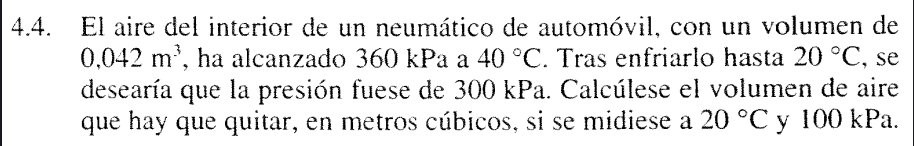

In [4]:
print("Realizado por Exergia Code : ")
#   Condiciones iniciales
V = 0.042  # m³ 
P1 = 360 * (1000) # Pa
T1 = 40 + 273.15  # K

#   Condiciones finales del gas extraido
P2 = 100 * (1000)  # Pa
T2 = 20 + 273.15  # K

#   Condiciones finales dentro del neumatico
P2_neumatico = 300 * 1000 # Pa
T2_neumatico = 20 + 273.15 # K

#   Desarrollo - delta_V = 0
R_gas = 8.3145    # Pa * m3 / mol.K = kJ/kmol.K = J/mol.K

# objetivo : determinar el volumen extraido  [=] m³ 
n_inicial = (P1 * V)/(R_gas * T1)
n_final = (P2_neumatico * V)/(R_gas * T2_neumatico)

print(f"la cantidad de moles en el estado inicial y final son respectivamente {n_inicial:,.4f} ; {n_final:,.4f} moles")

delta_n_moles = n_final - n_inicial

print(f"la cantidad de moles extraido es {-delta_n_moles:,.4f} moles")

Volumen_extraido = (R_gas * (-delta_n_moles) * T2) / P2

print(f"el volumen extraido de gas es {Volumen_extraido:,.4f} m³")
print(f"el volumen extraido de gas es {Volumen_extraido*1000:,.4f} L")

Realizado por Exergia Code : 
la cantidad de moles en el estado inicial y final son respectivamente 5.8072 ; 5.1695 moles
la cantidad de moles extraido es 0.6377 moles
el volumen extraido de gas es 0.0155 m³
el volumen extraido de gas es 15.5433 L


# Pagina 170 , 67 - Kenneth Wark

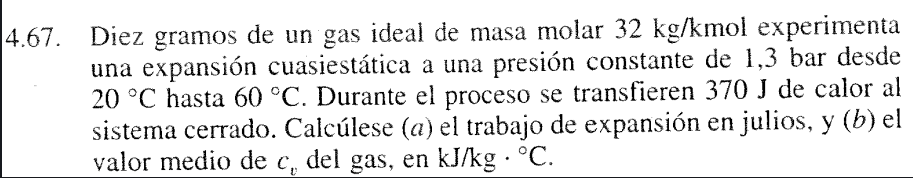

In [5]:
print("Realizado por Exergia Code : ")
#   Condiciones iniciales
R_gas = 8.3145              # J/mol.K = Pa .m³ / mol.K
masa_gas = 10 * (1/1000)    # kg
PM_gas = 32                 # kg / kmol
P_inicial = 1.3 * (100000)  # Pa
T_inicial = 20 +273.15      # K

#   Condiciones finales
P_final = P_inicial         # Pa
T_final = 60 +273.15        # K

#   Desarrollo - delta_P = 0
Q_transferido = 370         # J

#   Objetivos : determinar W_trabajo [=] J ; valor medio C_v [=] kJ/ kg.K
n_moles = masa_gas / PM_gas

V_inicial = (n_moles * R_gas * T_inicial) / P_inicial
V_final = (n_moles * R_gas * T_final) / P_final

delta_V = V_final - V_inicial

W_exp = - P_inicial * delta_V

print(f"El trabajo de expansión del gas es {W_exp:,.4f} J")

delta_U = Q_transferido + W_exp # J
delta_u = delta_U / masa_gas
delta_T = T_final - T_inicial

C_vmedio = (delta_u / delta_T) # J/kg.K
C_vmedio = C_vmedio * (1/1000) # kJ/kg.K

print(f"La capacidad calorífica media es {C_vmedio:,.4f} kJ/kg.K")

Realizado por Exergia Code : 
El trabajo de expansión del gas es -0.1039 J
La capacidad calorífica media es 0.9247 kJ/kg.K


# Página 171 , 74 - Kenneth Wark

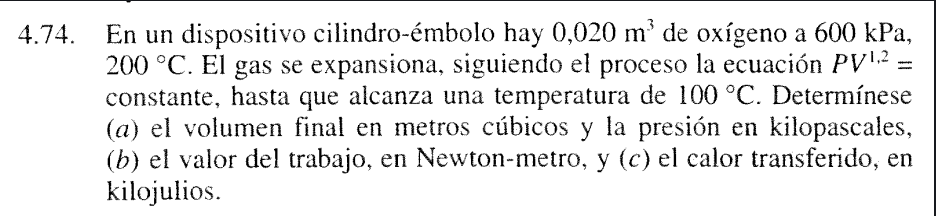

In [6]:
#   Condiciones iniciales - Oxígeno
R_gas     = 8.3145 # kJ/(kmol·K) ; kPa.m³ / kmol.K
PM_ox     = 32   # kg/kmol
V_inicial = 0.02 # m³
P_inicial = 600  # kPa
T_inicial = 200 + 273.15 # K
n_politropico = 1.2          # coeficiente politrópico

#   Condiciones finales
T_final = 100 + 273.15 # K

#   Desarrollo PV^1.2 =cte
#   Objetivo  : V_final [=] m³ P_final [=] kPa ; W [=] J ; Q [=] kJ
CTE = P_inicial * (V_inicial**n_politropico)

n_oxigeno = (P_inicial * V_inicial)/(R_gas * T_inicial) # kmol
m_oxigeno = PM_ox * n_oxigeno

print(f"{n_oxigeno:,.6f} {m_oxigeno:,.6f}")

V_final = V_inicial * ((T_inicial/T_final)**(1/(n_politropico-1)))
print(f"Volumen final {V_final:,.5f} m³")

P_final = (n_oxigeno * R_gas * T_final) / V_final
Pfinal2 = CTE * (V_final**n_politropico)
print(f"Presión final {P_final:,.5f} kPa ")

#   trabajo
V = sp.Symbol("V")
expresion = - CTE/(V**n_politropico)

W = sp.integrate(expresion,(V,V_inicial,V_final))

print(f"El trabajo realizado por el gas es {W:,.4f} kJ")

#   calor transferido
#   delta_u = Q + W

delta_u = delta_u_wark(
    T_inicial,
    T_final,
    3.626,
    -1.878e-3,
    7.056e-6,
    -6.764e-9,
    2.156e-12,
    PM_ox
)["delta_u_kJ_kmol"]

Q_transf = (n_oxigeno * delta_u) - W

print(f"El calor transferido es {Q_transf:,.4f} kJ")


0.003050 0.097610
Volumen final 0.06556 m³
Presión final 144.36398 kPa 
El trabajo realizado por el gas es -12.6810 kJ
El calor transferido es 5.9549 kJ


# Página 174 , 95 - Kenneth Wark

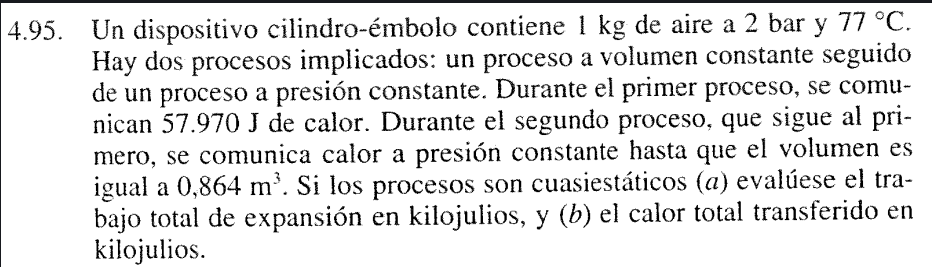

In [7]:
#   Condiciones etapa 1
R_gas = 8.3145      # kPa . m³ / kmol . K
m_aire = 1          # kg
P_1 = 2 * (100)     # kPa
T_1 = 77 + 273.15   # K

#   Condiciones etapa 2 - V_2 = V_1


#   Condiciones etapa 3 P_3 = P_2
V_3 = 0.864         # m³

#   Desarollo
Q_in_1_2 = 57970 / 1000 # kJ
PM_aire = 28.97 # kg/kmol
Cv_a = 3.653
Cv_b = -1.334e-3
Cv_c = 3.291e-6
Cv_d = -1.910e-9
Cv_e = 0.275e-12

#   Objetivos : a) W_total_exp [=] kJ ; b) Q_transf [=] kJ
#   Estado 1
n_moles = m_aire / PM_aire
V_1 = (n_moles * R_gas * T_1) / P_1
#   Estado 2
V_2 = V_1

def solucion_T_2(b) :
    delta_u = delta_u_wark(
        T_1,
        b,
        Cv_a,
        Cv_b,
        Cv_c,
        Cv_d,
        Cv_e,
        PM_aire
    )["delta_u_kJ_kmol"]
    return delta_u * n_moles - Q_in_1_2

T_2 = newton(solucion_T_2, x0=T_1*1.001)
print(f"la temperatura en el estado 2 es {T_2:,.4f} K")
P_2 = (n_moles * R_gas * T_2) / V_2

#   Estado 3
P_3 = P_2
T_3 = (P_3*V_3) / (n_moles * R_gas)
print(f"la temperatura en el estado 3 es {T_3:,.4f} K")
V = sp.Symbol("V")
expresion = - P_3
W_generado = sp.integrate(expresion,(V, V_2,V_3))

print(f"El trabajo de expansión total es de {W_generado:,.4f} kJ")

#   calor transferido

delta_u_2_3 = delta_u_wark(
    T_2,
    T_3,
    Cv_a,
    Cv_b,
    Cv_c,
    Cv_d,
    Cv_e,
    PM_aire
)["delta_u_kJ_kmol"]

Q_in_2_3 = (delta_u_2_3 * n_moles) - W_generado

Q_total = Q_in_1_2 + Q_in_2_3

print(f"El calor total transferido en todos los procesos es de {Q_total:,.4f} kJ")


la temperatura en el estado 2 es 430.0767 K
la temperatura en el estado 3 es 739.5165 K
El trabajo de expansión total es de -88.8104 kJ
El calor total transferido en todos los procesos es de 382.3583 kJ


# Página 200 , 10 - Yunus Çengel

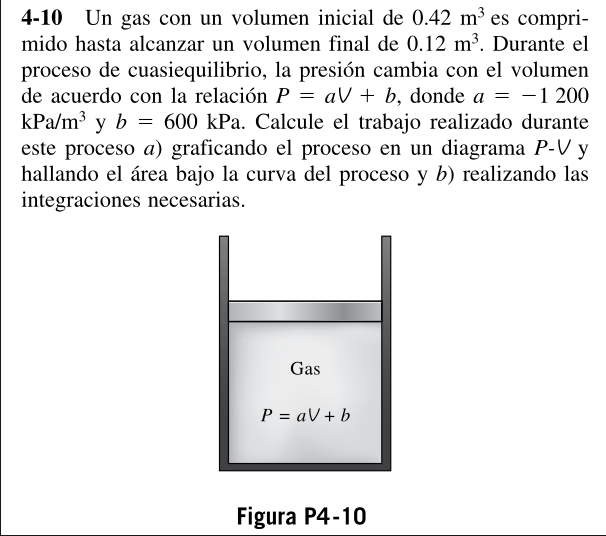

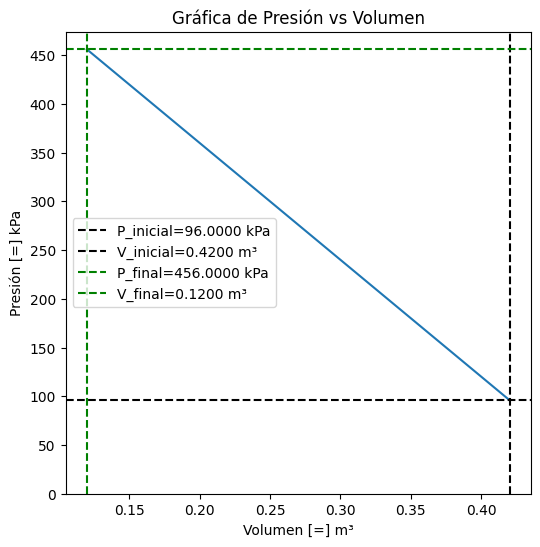

El trabajo de compresión por método gráfico es: 82.80 kJ
El trabajo de compresión por método analítico es: 82.80 kJ


In [9]:
#   Condiciones iniciales
R_gas = 8.3145  # kPa.m³ / Kmol.K
V_i = 0.42      # m³

#   Condiciones iniciales
V_f = 0.12      # m³

#   Desarrollo
a_cte = -1200   # kPa / m³
b_cte = 600     # kPa

def P_lineal(V):
    P = a_cte * V + b_cte
    return P

#   Objetivos : W_realizado 

# a) método gráfico
V_lista = np.linspace(V_i, V_f, 1000)
P_lista = [P_lineal(V) for V in V_lista]

plt.figure(figsize=(6,6))
plt.plot(V_lista, P_lista)
plt.title("Gráfica de Presión vs Volumen")
plt.ylabel("Presión [=] kPa")
plt.xlabel("Volumen [=] m³")
plt.yticks(np.arange(0, int(max(P_lista)), 50))
plt.axhline(y=P_lista[0], linestyle="--", color="black", label=f"P_inicial={P_lista[0]:,.4f} kPa")
plt.axvline(x=V_lista[0], linestyle="--", color="black", label=f"V_inicial={V_lista[0]:,.4f} m³")
plt.axhline(y=P_lista[-1], linestyle="--", color="green", label=f"P_final={P_lista[-1]:,.4f} kPa")
plt.axvline(x=V_lista[-1], linestyle="--", color="green", label=f"V_final={V_lista[-1]:,.4f} m³")
plt.legend()
plt.show()

b_triangulo = V_lista[-1] - V_lista[0]
h_triangulo = P_lista[-1] - P_lista[0]
b_rectangulo = b_triangulo 
h_rectangulo = P_lista[0]

A_triangulo = (b_triangulo * h_triangulo) / 2
A_rectangulo = b_rectangulo * h_rectangulo
W_compresion = - (A_triangulo + A_rectangulo)

print(f"El trabajo de compresión por método gráfico es: {W_compresion:,.2f} kJ")

# b) método analítico

V = sp.Symbol("V")
expresion = - (a_cte * V + b_cte)
W_compresion_analitico = sp.integrate(expresion,(V, V_i, V_f))

print(f"El trabajo de compresión por método analítico es: {W_compresion_analitico:,.2f} kJ")

# Página 205 - 65 Cengel Yunus

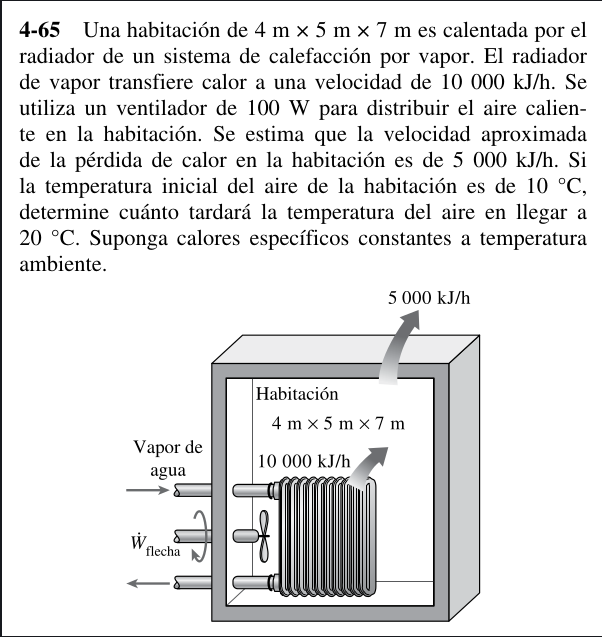